In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
df = pd.read_csv('retail_customer_segmentation.csv')
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,Card,Semi-Urban,Occasional
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,Wallet,Urban,Occasional
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,UPI,Rural,Occasional
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,Wallet,Rural,High_Value
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,Card,Semi-Urban,Occasional


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          46925 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      47480 non-null  float64
 5   purchase_frequency     48021 non-null  float64
 6   avg_order_value        50000 non-null  float64
 7   discount_usage_rate    47451 non-null  float64
 8   return_rate            47513 non-null  float64
 9   browsing_time_minutes  46066 non-null  float64
 10  support_interactions   48012 non-null  float64
 11  payment_method         50000 non-null  object 
 12  region                 50000 non-null  object 
 13  customer_segment       50000 non-null  object 
dtypes: float64(8), int64(3), object(3)
memory usage: 5.3+ 

In [4]:
df = df.drop(columns='customer_id')

In [5]:
df.describe()

,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,50000.000000,46925.000000,50000.000000,47480.000000,48021.000000,50000.000000,47451.000000,47513.000000,46066.000000,48012.000000
mean,44.002820,44542.620904,36.477480,337.294238,4.910841,77.375915,0.284358,0.148964,61.781329,1.494606
std,15.269871,30537.946035,20.787197,204.627095,3.416115,70.531793,0.159236,0.110508,41.743394,1.221280
min,18.000000,2946.317892,1.000000,8.072298,0.017013,0.940393,0.000534,0.000050,0.236109,0.000000
25%,31.000000,24373.244554,18.000000,192.074544,2.456867,32.018468,0.160497,0.063938,31.082283,1.000000
50%,44.000000,36787.730010,36.000000,297.477404,4.158673,56.600351,0.262591,0.123628,52.679175,1.000000
75%,57.000000,55497.245522,55.000000,439.112361,6.526903,98.832037,0.387640,0.209612,82.549571,2.000000
max,70.000000,530788.317921,72.000000,3026.342238,67.682528,1289.427328,0.934655,0.830395,406.813006,9.000000


In [6]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['age', 'annual_income', 'months_active', 'avg_monthly_spend',
       'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
       'return_rate', 'browsing_time_minutes', 'support_interactions'],
      dtype='object')

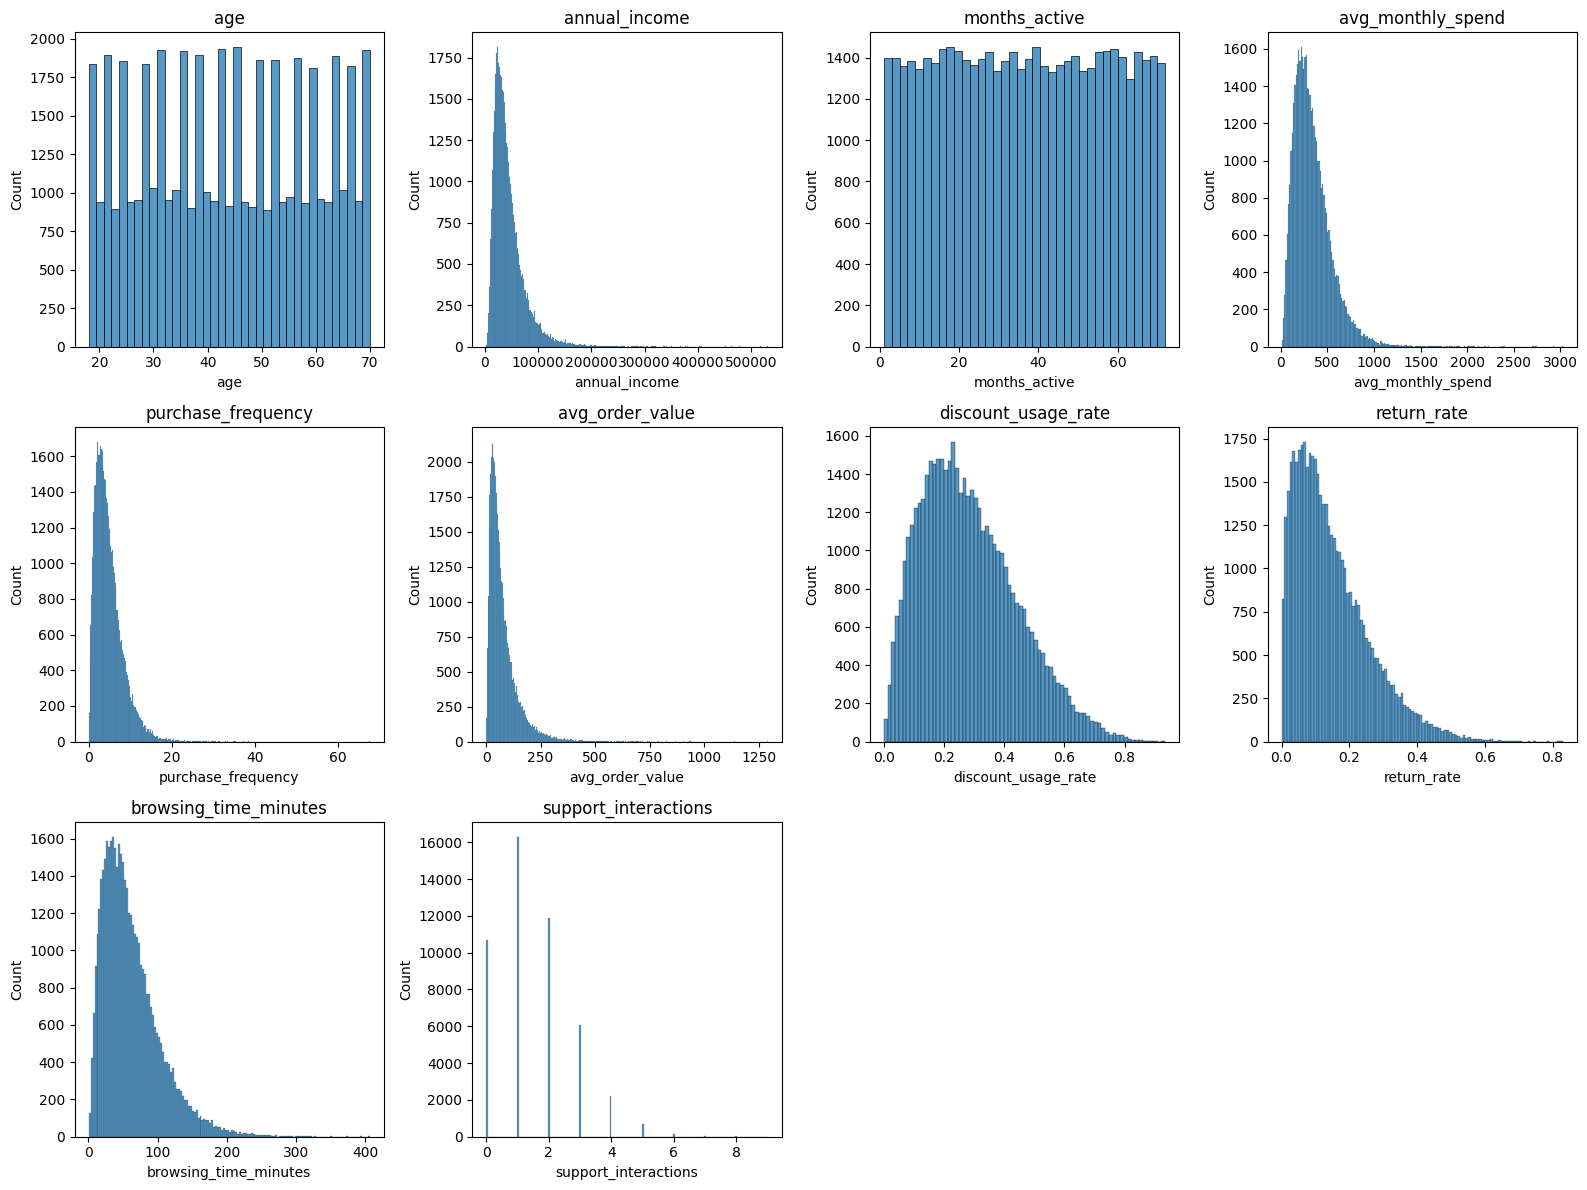

In [7]:
rows = (len(num_cols) + 3) // 4 # dynamic rows 
_, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df, x=col, bins='auto', ax=ax)
    ax.set_title(col)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
cat_cols = df.select_dtypes(exclude='number').columns
cat_cols

Index(['payment_method', 'region', 'customer_segment'], dtype='object')

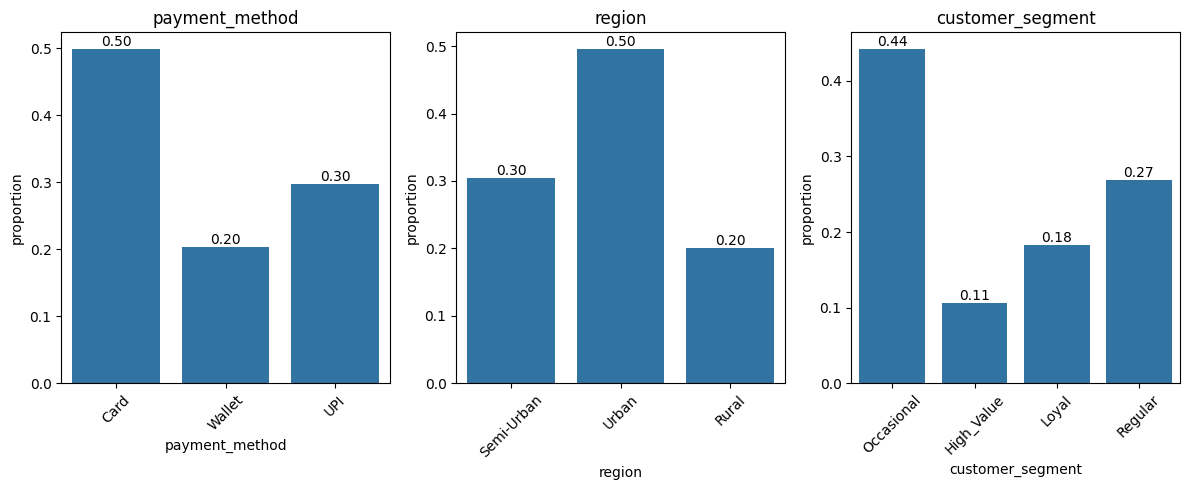

In [9]:
# Graphical Representation of qualitative columns

_, axes = plt.subplots(1, 3, figsize=(12, 5))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax, stat='proportion')
    ax.bar_label(ax.containers[0], fmt='%.2f')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---

## **Handling Null Values**

Identifying Missing values in each column

In [10]:
na_by_cols = df.isna().sum() / df.shape[0] * 100

In [11]:
na_by_cols

age                      0.000
annual_income            6.150
months_active            0.000
avg_monthly_spend        5.040
purchase_frequency       3.958
avg_order_value          0.000
discount_usage_rate      5.098
return_rate              4.974
browsing_time_minutes    7.868
support_interactions     3.976
payment_method           0.000
region                   0.000
customer_segment         0.000
dtype: float64

If we go by the rule of thumb, we can safely remove the rows with missing values on columnswith less that 5% missing values, and potentially drop the ones below 10% percent as well. 

In [12]:
rows_with_missing = df.isna().any(axis=1).sum()
proportion_rows_with_missing = df.isna().any(axis=1).mean()
print(proportion_rows_with_missing)

0.31722


However, we found that combined 31.72% of the rows have at least one missing value, which is a lot, so removing them would result in significant loss in healthy data in other columns. 

- So let's study the nature of the missing data first before we decide on how to handle it.

### **Studying Missingness Nature**

We will study the distribution of columns without missing data before and after the removal of rows with missing values to see if there is a significant difference in the distribution, which would indicate that the missing data is not random and may be related to the values in those columns.

In [13]:
NA_list = []
NoNA_list = []

for i in range(len(na_by_cols)):
    if na_by_cols.values[i] > 0:
        NA_list.append(na_by_cols.index[i])
    else:
        NoNA_list.append(na_by_cols.index[i])

In [14]:
# Columns that has missing values

NA_list

['annual_income',
 'avg_monthly_spend',
 'purchase_frequency',
 'discount_usage_rate',
 'return_rate',
 'browsing_time_minutes',
 'support_interactions']

In [15]:
# Columns with no missing values

NoNA_list

['age',
 'months_active',
 'avg_order_value',
 'payment_method',
 'region',
 'customer_segment']

In [16]:
# Dropping the rows with missing value for comparison

cleaned_data = df.dropna()

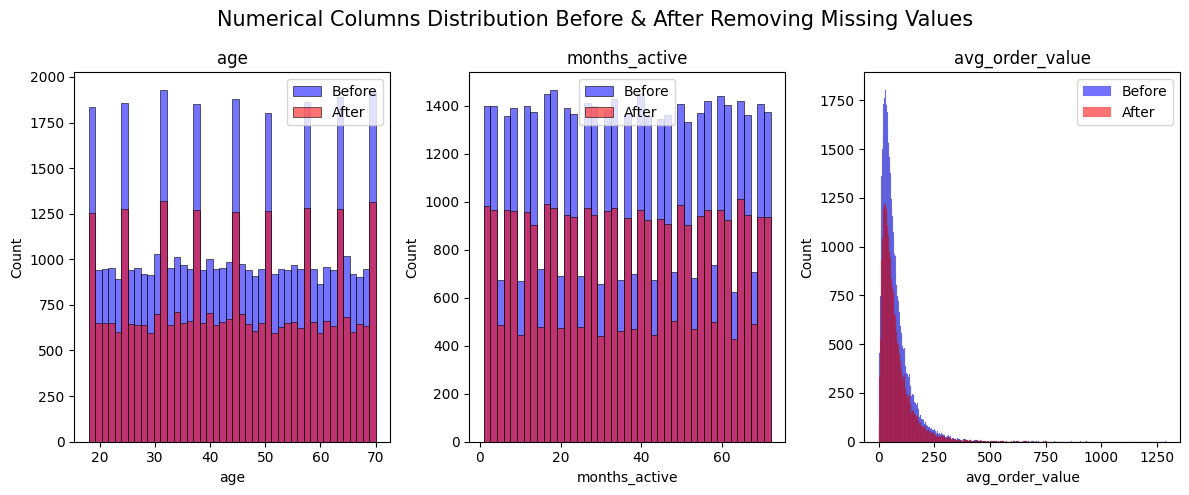

In [17]:
num_NoNA = [col for col in NoNA_list if col in num_cols]

_, axes = plt.subplots(1, 3, figsize=(12, 5))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, num_NoNA):
    combined = pd.concat([df[col], cleaned_data[col]]).dropna()
    _, bin_edges = np.histogram(combined, bins='auto')

    sns.histplot(df, x=col, ax=ax, bins=bin_edges, label='Before', alpha=0.55, color='blue')
    sns.histplot(cleaned_data, x=col, ax=ax, bins=bin_edges, label='After', alpha=0.55, color='red')
    ax.set_title(col)
    ax.legend()

plt.suptitle('Numerical Columns Distribution Before & After Removing Missing Values', fontsize=15)
plt.tight_layout()
plt.show()

We can see that is no significant difference in the distribution of the numerical columns without missing data before and after the removal of rows with missing values and they actually closely follow the same distribution, which indicates that the missing data is random and not related to the values in those columns. 

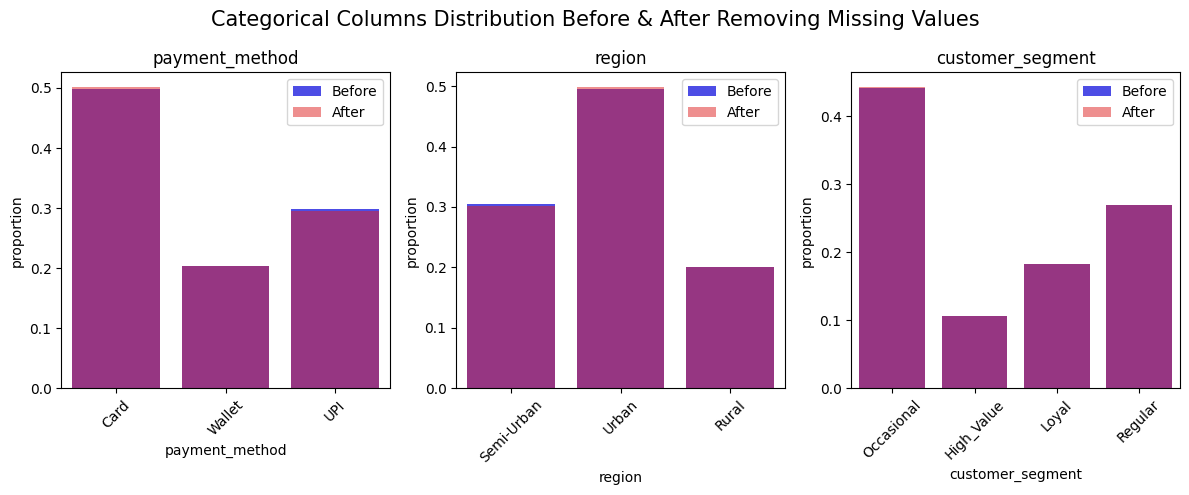

In [18]:
cat_NoNA = [col for col in NoNA_list if col not in num_cols]

_, axes = plt.subplots(1, 3, figsize=(12, 5))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, cat_NoNA):
    sns.countplot(data=df, x=col, ax=ax, stat='proportion', label='Before', color='blue', alpha=0.8)
    sns.countplot(data=cleaned_data, x=col, ax=ax, stat='proportion', label='After', color='red', alpha=0.5)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.suptitle('Categorical Columns Distribution Before & After Removing Missing Values', fontsize=15)
plt.tight_layout()
plt.show()

Similarly, the non-missing categorical columns also see no proportion change after the removal of rows with missing values, which further supports the conclusion that the missing data is random and not related to the values in those columns.

From this, we can conclude that the nature of the missingness is **Missing Completely at Random (MCAR)**

- Therefore, we should be able to safely remove the rows with missing values without introducing bias to our analysis.a

But then again, from earlier, removing them all is removing 31% of our total 50,000 rows, so I think it wouldn't hurt to just **impute them with the median** instead

In [19]:
df[NA_list] = df[NA_list].fillna(df[NA_list].median())

In [20]:
df.isna().sum()

age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64

---

## **Handling Outliers**

Checking min and max values of numerical columns to identify potential outliers

In [21]:
df.describe()

,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,44.002820,44065.695114,36.477480,335.287469,4.881070,77.375915,0.283248,0.147704,61.065171,1.47494
std,15.269871,29642.592692,20.787197,199.593893,3.351036,70.531793,0.155198,0.107865,40.142412,1.20065
min,18.000000,2946.317892,1.000000,8.072298,0.017013,0.940393,0.000534,0.000050,0.236109,0.00000
25%,31.000000,25112.704208,18.000000,197.220824,2.526421,32.018468,0.166100,0.066834,32.836514,1.00000
50%,44.000000,36787.730010,36.000000,297.477404,4.158673,56.600351,0.262591,0.123628,52.679175,1.00000
75%,57.000000,53830.215138,55.000000,429.191654,6.399534,98.832037,0.380198,0.203893,79.367471,2.00000
max,70.000000,530788.317921,72.000000,3026.342238,67.682528,1289.427328,0.934655,0.830395,406.813006,9.00000


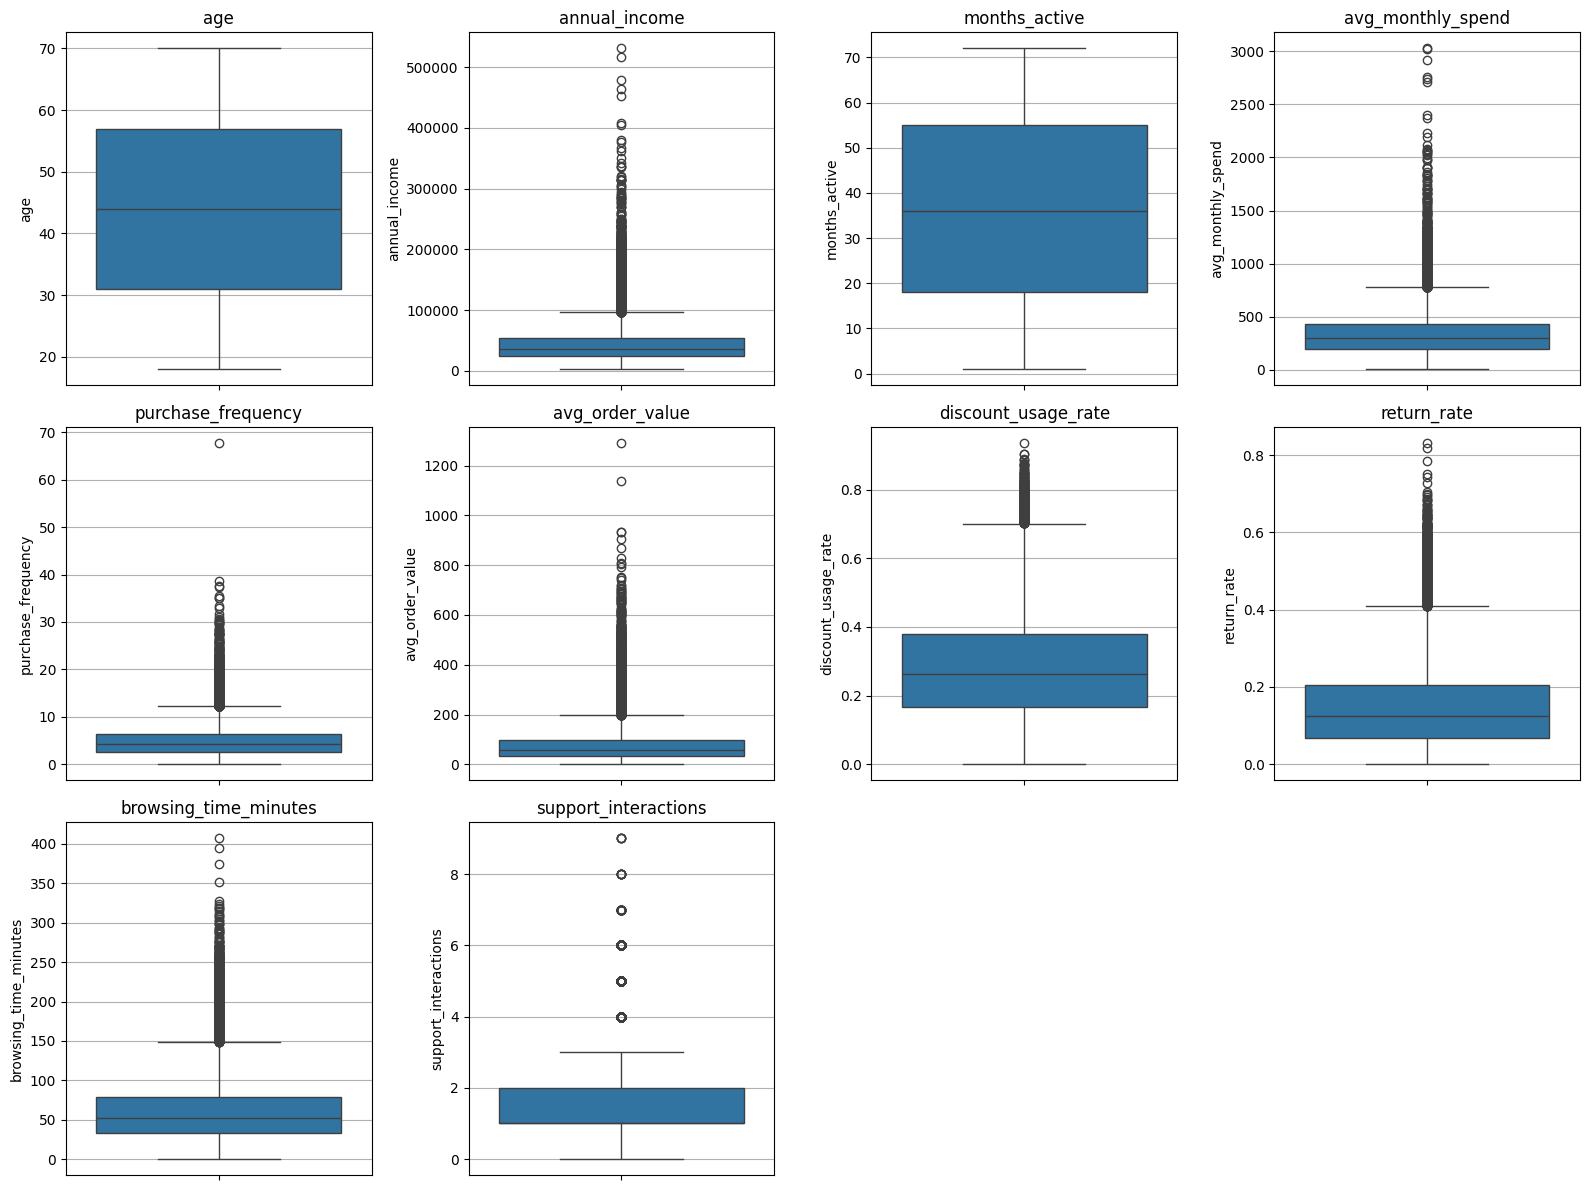

In [22]:
rows = (len(num_cols) + 3) // 4
_, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(df, y=col, ax=ax)
    ax.set_title(col)
    ax.grid(axis='y')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Although we can see some extreme values in the max values compared to its median for most of the columns except age and months active, we will not deal with them for now as they all seem reasonable enough to happen in real life and not from the result of an error.

- Keeping them in our dataset could also be beneficial as they can help us identify high-value customers and their characteristics, which is important for customer segmentation.

---

# **Exploratory Data Analysis**

Finding the relationship between columns and identifying potential patterns in the data that can help us in customer segmentation

Before looking into potential meaningful relationships between the columns let's build a matrix that we can get a holistic view of the relationships between all the columns in one place, and then we can look into specific relationships that we find interesting.

In [23]:
from scipy import stats
from scipy.stats import chi2_contingency
import itertools

We want the matrix heatmap to be consistent with valuescranging from 0 to 1 so we will use these metrics for each combination of columns:

- Numerical-Numerical: We will use **Spearman's correlation coefficient** to find monotonic relationships and is not affected by outliers.
- Numerical-categorical: we will use **eta_squared** to find the strength of association between the numerical and categorical variables.
- Categorical-categorical: we will use **Cramer's V** to normalize chi-square values between 0 and 11

In [24]:
# Helper functions to calculate cramers_v and eta_squared

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r - 1, k - 1))

def eta_squared(numerical, categorical):
    groups = [numerical[categorical == cat].dropna() 
              for cat in categorical.unique()]
    grand_mean = numerical.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = ((numerical - grand_mean)**2).sum()
    return ss_between / ss_total if ss_total != 0 else 0


In [25]:
all_cols = df.columns.to_list()
all_cols

['age',
 'annual_income',
 'months_active',
 'avg_monthly_spend',
 'purchase_frequency',
 'avg_order_value',
 'discount_usage_rate',
 'return_rate',
 'browsing_time_minutes',
 'support_interactions',
 'payment_method',
 'region',
 'customer_segment']

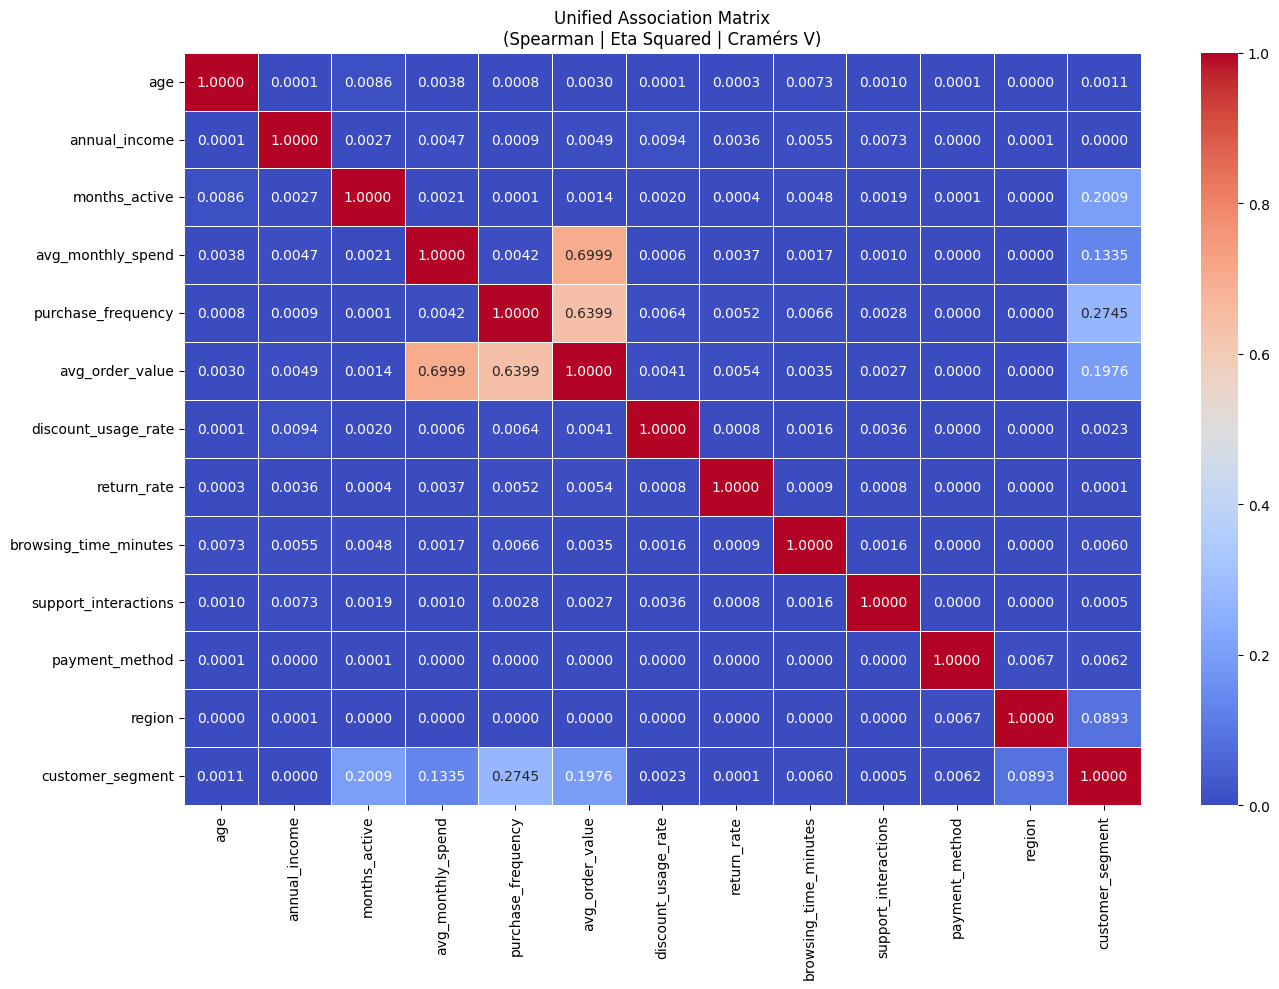

In [26]:
# Build empty matrix
corr_matrix = pd.DataFrame(np.zeros((len(all_cols), len(all_cols))),
                            index=all_cols, columns=all_cols)

# Fill matrix
for col1, col2 in itertools.combinations_with_replacement(all_cols, 2):
    if col1 == col2:
        corr_matrix.loc[col1, col2] = 1.0
    elif col1 in num_cols and col2 in num_cols:
        r, _ = stats.spearmanr(df[col1], df[col2])
        corr_matrix.loc[col1, col2] = abs(r)
        corr_matrix.loc[col2, col1] = abs(r)
    elif col1 in cat_cols and col2 in cat_cols:
        v = cramers_v(df[col1], df[col2])
        corr_matrix.loc[col1, col2] = v
        corr_matrix.loc[col2, col1] = v
    else:
        num = col1 if col1 in num_cols else col2
        cat = col1 if col1 in cat_cols else col2
        eta2 = eta_squared(df[num], df[cat][df[num].notna()])
        corr_matrix.loc[num, cat] = eta2
        corr_matrix.loc[cat, num] = eta2

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
            vmin=0, vmax=1, linewidths=0.5)
plt.title('Unified Association Matrix\n(Spearman | Eta Squared | Cramérs V)')
plt.tight_layout()
plt.show()

### Numerical-Numerical Relationships Scatterplots

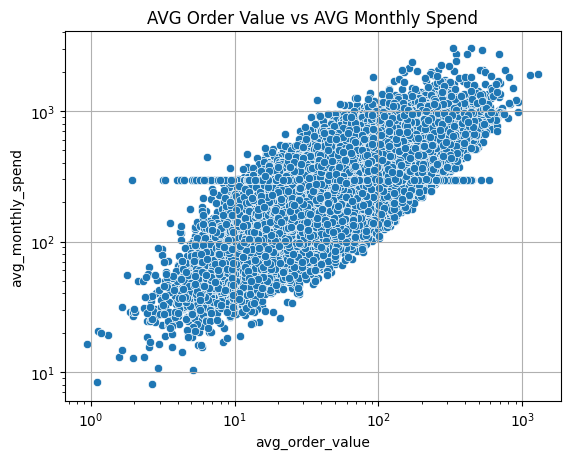

In [27]:
sns.scatterplot(data=df, x='avg_order_value', y='avg_monthly_spend')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.title("AVG Order Value vs AVG Monthly Spend")
plt.show()

From the graph we see a positive linear relationship between avg_order_value and avg_monthly_spend meaning that as the average order value increases, the average monthly spend also increases, which is expected as the more a customer spends on average per order, the more those valyes add up to the montly spend.

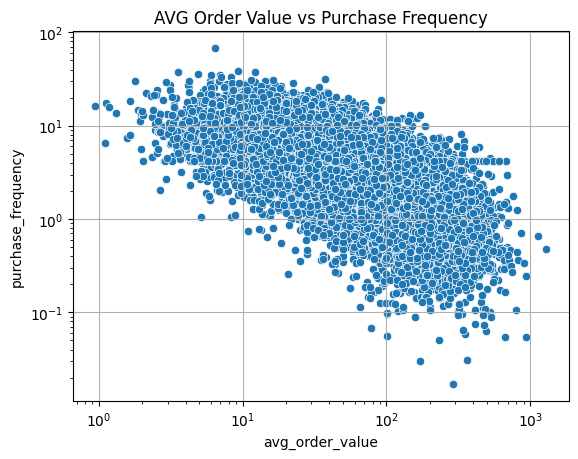

In [28]:
sns.scatterplot(data=df, x='avg_order_value', y='purchase_frequency')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.title("AVG Order Value vs Purchase Frequency")
plt.show()

From this we seem to see a negative linear relationship between avg_order_value and purchase_frequency, which is interesting as this could indicate that customers who make more frequent purchases tend to have lower average order values, or there might be some other underlying factor at play.

From these two visualizations, it seems The Average Order Value of a customer is postively correlated with their Average Monthly Spend, and negatively correlated with their Purchase Frequency. 

But from the column description, we know that **avg_order_value is calculated by dividing avg_monthly_spend by purchase_frequency**, so these relationships are expected and make sense mathematically as well.

### **Studying our Target Label Relationship**

Because our target label is categorical, we will look into the relationship between it and the numerical columns using grouped boxplots, and with the categorical columns using stacked countplots.

### Numerical-Categorical Relationship with Grouped Boxplots


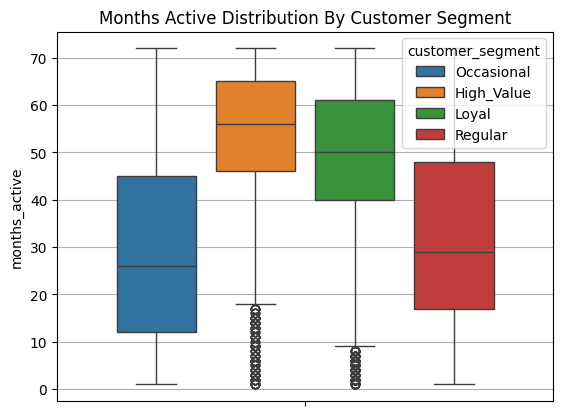

In [29]:
sns.boxplot(df, y='months_active', hue='customer_segment', gap=0.2)
plt.title("Months Active Distribution By Customer Segment")
plt.grid(axis='y')
plt.show()

We can visually see a difference in the distribution of the numerical columns across the different categories of the target label, which indicates that there is a relationship between them.

- Customers in the 'High Value' segment tend to have been active for a longer time within around 47-65 months, followed by Loyal customer segment with around 40-61 months, and then the 'regular' segment with around 18-48 months, and occasional customers with around 12-45 months.

- Notably, the high value and loyal customer segments also have outliers that have been active for shorter amount of time, which could indicate that they have other behaviors that make them high value or loyal customers despite being active for a shorter time.

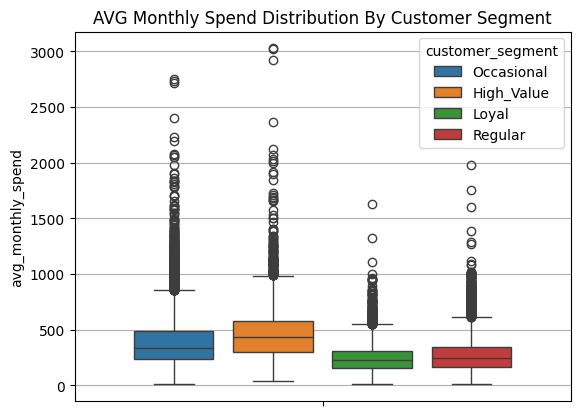

In [30]:
sns.boxplot(df, y='avg_monthly_spend', hue='customer_segment', gap=0.2)
plt.title("AVG Monthly Spend Distribution By Customer Segment")
# plt.yscale('log')
plt.grid(axis='y')
plt.show()

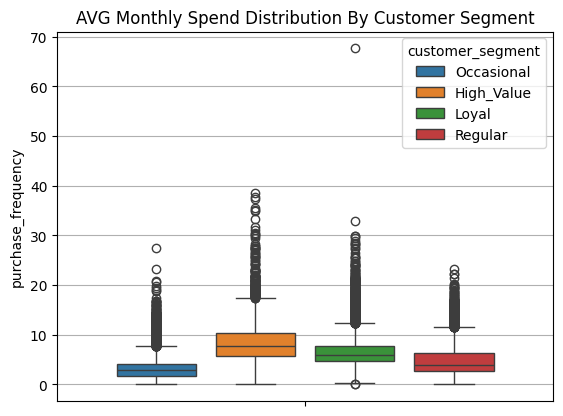

In [31]:
sns.boxplot(df, y='purchase_frequency', hue='customer_segment', gap=0.2)
plt.title("AVG Monthly Spend Distribution By Customer Segment")
# plt.yscale('log')
plt.grid(axis='y')
plt.show()

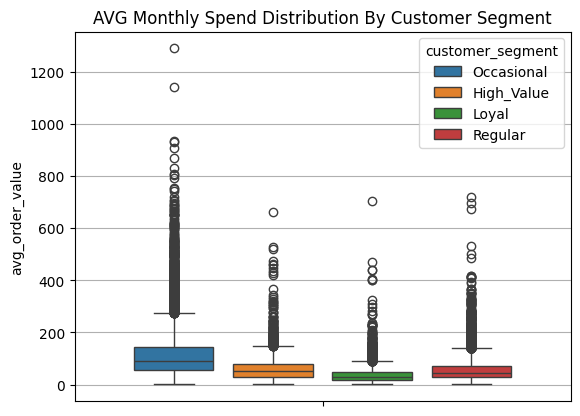

In [32]:
sns.boxplot(df, y='avg_order_value', hue='customer_segment', gap=0.2)
plt.title("AVG Monthly Spend Distribution By Customer Segment")
# plt.yscale('log')
plt.grid(axis='y')
plt.show()

### Categorical-Categorical Relationship with Stacked Countplots 

In [37]:
fig1 = px.histogram(df, x='customer_segment', color='region')
fig1.update_layout(width=600, height=400, title='Customer Segment By Region')
fig1.show()